# Лабораторная работа №5
## Классификация моторного воображения по данным ЭЭГ

В этой версии решения используется **самостоятельная реализация**:
- данные ищутся автоматически внутри `/kaggle/input`;
- сигналы нормируются по каждой записи;
- для временно-частотного представления применяется **CWT** с wavelet `morl`;
- изображения приводятся к размеру `96 x 96`;
- модель построена на **PyTorch**, а не на Keras;
- используется отдельная валидационная выборка и сохраняется лучшая модель.

Ожидаемые файлы:
- `MI-EEG-B9T.csv`
- `MI-EEG-B9E.csv`
- `class_MI_EEG_train_9.csv`
- `class_MI_EEG_test_9.csv`

In [5]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [7]:
import re
from pathlib import Path

csv_files = sorted([p for p in INPUT_ROOT.rglob("*.csv") if p.is_file()])

def file_name(p):
    return p.name.lower()

def is_target_file(p):
    n = file_name(p)
    return n.startswith("class_") or "target" in n or "label" in n

signal_files = [p for p in csv_files if not is_target_file(p)]
target_files = [p for p in csv_files if is_target_file(p)]

def choose_file(candidates, patterns):
    compiled = [re.compile(x) for x in patterns]
    scored = []
    for p in candidates:
        n = file_name(p)
        score = sum(1 for pat in compiled if pat.search(n))
        scored.append((score, p))
    scored = sorted(scored, key=lambda x: (x[0], x[1].name), reverse=True)
    if len(scored) == 0:
        return None
    if scored[0][0] == 0:
        return None
    return scored[0][1]

train_signal_path = choose_file(signal_files, [r"train", r"b9t", r"_t\.csv$"])
test_signal_path  = choose_file(signal_files, [r"test", r"b9e", r"_e\.csv$"])

train_target_path = choose_file(target_files, [r"train"])
test_target_path  = choose_file(target_files, [r"test"])

if train_signal_path is None and len(signal_files) >= 1:
    train_signal_path = signal_files[0]

if test_signal_path is None and len(signal_files) >= 2:
    test_signal_path = signal_files[1]

if train_target_path is None and len(target_files) >= 1:
    train_target_path = target_files[0]

if test_target_path is None and len(target_files) >= 2:
    test_target_path = target_files[1]

if train_signal_path == test_signal_path and len(signal_files) >= 2:
    test_signal_path = signal_files[1]

if train_target_path == test_target_path and len(target_files) >= 2:
    test_target_path = target_files[1]

print("Signal files found:")
for p in signal_files:
    print(" ", p)

print("\nTarget files found:")
for p in target_files:
    print(" ", p)

print("\nSelected files:")
print("Train signals:", train_signal_path)
print("Test signals :", test_signal_path)
print("Train target :", train_target_path)
print("Test target  :", test_target_path)

if train_signal_path is None or test_signal_path is None or train_target_path is None or test_target_path is None:
    raise FileNotFoundError("Could not automatically determine all four required CSV files.")


Signal files found:
  /kaggle/input/datasets/ahmadhamed1046/lab-5-samara1/MI-EEG-B9T.csv
  /kaggle/input/datasets/ahmadhamed1046/lab05-sa1/MI-EEG-B9T.csv
  /kaggle/input/datasets/ahmadhamed1046/lab05-sa12/MI-EEG-B9T.csv
  /kaggle/input/datasets/ahmadhamed1046/lab05-sa13/MI-EEG-B9E.csv
  /kaggle/input/datasets/ahmadhamed1046/lab05-sa2/2class_MI_EEG_test_9.csv
  /kaggle/input/datasets/ahmadhamed1046/lab05-samara3/2class_MI_EEG_train_9.csv

Target files found:

Selected files:
Train signals: /kaggle/input/datasets/ahmadhamed1046/lab-5-samara1/MI-EEG-B9T.csv
Test signals : /kaggle/input/datasets/ahmadhamed1046/lab05-sa13/MI-EEG-B9E.csv
Train target : None
Test target  : None


FileNotFoundError: Could not automatically determine all four required CSV files.

In [8]:
from pathlib import Path

train_signal_path = Path("/kaggle/input/datasets/ahmadhamed1046/lab-5-samara1/MI-EEG-B9T.csv")
test_signal_path  = Path("/kaggle/input/datasets/ahmadhamed1046/lab05-sa13/MI-EEG-B9E.csv")

train_target_path = Path("/kaggle/input/datasets/ahmadhamed1046/lab05-samara3/2class_MI_EEG_train_9.csv")
test_target_path  = Path("/kaggle/input/datasets/ahmadhamed1046/lab05-sa2/2class_MI_EEG_test_9.csv")

print("Train signals:", train_signal_path)
print("Test signals :", test_signal_path)
print("Train target :", train_target_path)
print("Test target  :", test_target_path)

for p in [train_signal_path, test_signal_path, train_target_path, test_target_path]:
    print(p, "->", p.exists())

Train signals: /kaggle/input/datasets/ahmadhamed1046/lab-5-samara1/MI-EEG-B9T.csv
Test signals : /kaggle/input/datasets/ahmadhamed1046/lab05-sa13/MI-EEG-B9E.csv
Train target : /kaggle/input/datasets/ahmadhamed1046/lab05-samara3/2class_MI_EEG_train_9.csv
Test target  : /kaggle/input/datasets/ahmadhamed1046/lab05-sa2/2class_MI_EEG_test_9.csv
/kaggle/input/datasets/ahmadhamed1046/lab-5-samara1/MI-EEG-B9T.csv -> True
/kaggle/input/datasets/ahmadhamed1046/lab05-sa13/MI-EEG-B9E.csv -> True
/kaggle/input/datasets/ahmadhamed1046/lab05-samara3/2class_MI_EEG_train_9.csv -> True
/kaggle/input/datasets/ahmadhamed1046/lab05-sa2/2class_MI_EEG_test_9.csv -> True


In [9]:
X_train_raw = pd.read_csv(train_signal_path, header=None).values.astype(np.float32)
X_test_raw  = pd.read_csv(test_signal_path, header=None).values.astype(np.float32)

y_train_raw = pd.read_csv(train_target_path, header=None).values.squeeze()
y_test_raw  = pd.read_csv(test_target_path, header=None).values.squeeze()

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
print("y_train_raw:", y_train_raw.shape)
print("y_test_raw :", y_test_raw.shape)

print("\nTrain labels:")
print(pd.Series(y_train_raw).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(y_test_raw).value_counts().sort_index())

X_train_raw: (400, 3000)
X_test_raw : (320, 3000)
y_train_raw: (400,)
y_test_raw : (320,)

Train labels:
0    200
1    200
Name: count, dtype: int64

Test labels:
0    160
1    160
Name: count, dtype: int64


In [10]:
def standardize_rows(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

X_train = standardize_rows(X_train_raw)
X_test = standardize_rows(X_test_raw)

print("Example train mean:", float(X_train[0].mean()))
print("Example train std :", float(X_train[0].std()))

Example train mean: -3.5762786065873797e-09
Example train std : 1.0000004768371582


In [11]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw).astype(np.float32)
y_test = label_encoder.transform(y_test_raw).astype(np.float32)

class_names = [str(x) for x in label_encoder.classes_]
class_mapping = {str(label): int(idx) for idx, label in enumerate(label_encoder.classes_)}

print("Classes:", class_names)
print("Mapping:", class_mapping)

Classes: ['0', '1']
Mapping: {'0': 0, '1': 1}


In [14]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/lab5_results")
PLOTS_DIR = OUTPUT_DIR / "plots"
MODELS_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

for d in [PLOTS_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PLOTS_DIR =", PLOTS_DIR)
print("MODELS_DIR =", MODELS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PLOTS_DIR = /kaggle/working/lab5_results/plots
MODELS_DIR = /kaggle/working/lab5_results/models
RESULTS_DIR = /kaggle/working/lab5_results/results


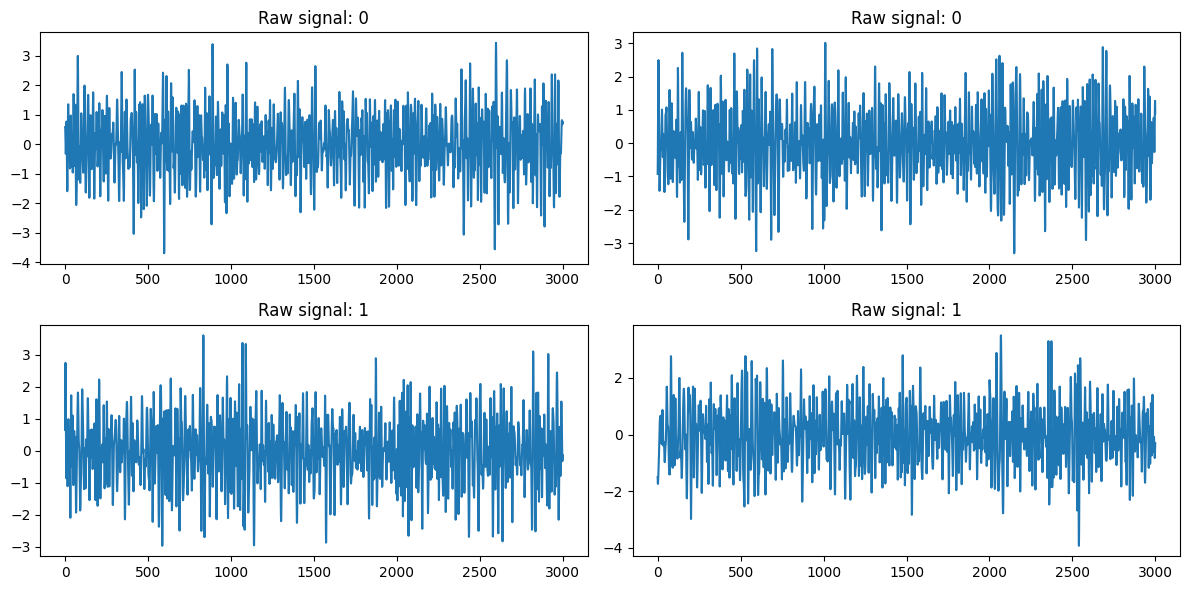

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.ravel()

idx0 = np.where(y_train == 0)[0][:2]
idx1 = np.where(y_train == 1)[0][:2]

for ax, idx in zip(axes[:2], idx0):
    ax.plot(X_train[idx])
    ax.set_title(f"Raw signal: {class_names[0]}")

for ax, idx in zip(axes[2:], idx1):
    ax.plot(X_train[idx])
    ax.set_title(f"Raw signal: {class_names[1]}")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "raw_signals.png", dpi=200)
plt.show()

In [16]:
SCALES = np.arange(1, 49)
IMG_SIZE = 96
WAVELET = "morl"

def resize_signal(signal_1d, target_length=512):
    x_old = np.linspace(0, 1, len(signal_1d))
    x_new = np.linspace(0, 1, target_length)
    return np.interp(x_new, x_old, signal_1d).astype(np.float32)

def signal_to_scalogram(signal_1d):
    signal_1d = np.asarray(signal_1d, dtype=np.float32)

    if len(signal_1d) != 512:
        signal_1d = resize_signal(signal_1d, 512)

    coeffs, _ = pywt.cwt(signal_1d, SCALES, WAVELET)
    img = np.abs(coeffs).astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    rgba = plt.cm.magma(img)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    rgb = Image.fromarray(rgb).resize((IMG_SIZE, IMG_SIZE))

    return np.asarray(rgb, dtype=np.float32) / 255.0

def build_scalogram_dataset(X, name="dataset"):
    out = []
    for i in range(X.shape[0]):
        out.append(signal_to_scalogram(X[i]))
        if (i + 1) % 100 == 0:
            print(f"{name}: processed {i + 1}/{X.shape[0]}")
    return np.stack(out)

X_train_img = build_scalogram_dataset(X_train, name="train")
X_test_img = build_scalogram_dataset(X_test, name="test")

print("X_train_img:", X_train_img.shape)
print("X_test_img :", X_test_img.shape)

train: processed 100/400
train: processed 200/400
train: processed 300/400
train: processed 400/400
test: processed 100/320
test: processed 200/320
test: processed 300/320
X_train_img: (400, 96, 96, 3)
X_test_img : (320, 96, 96, 3)


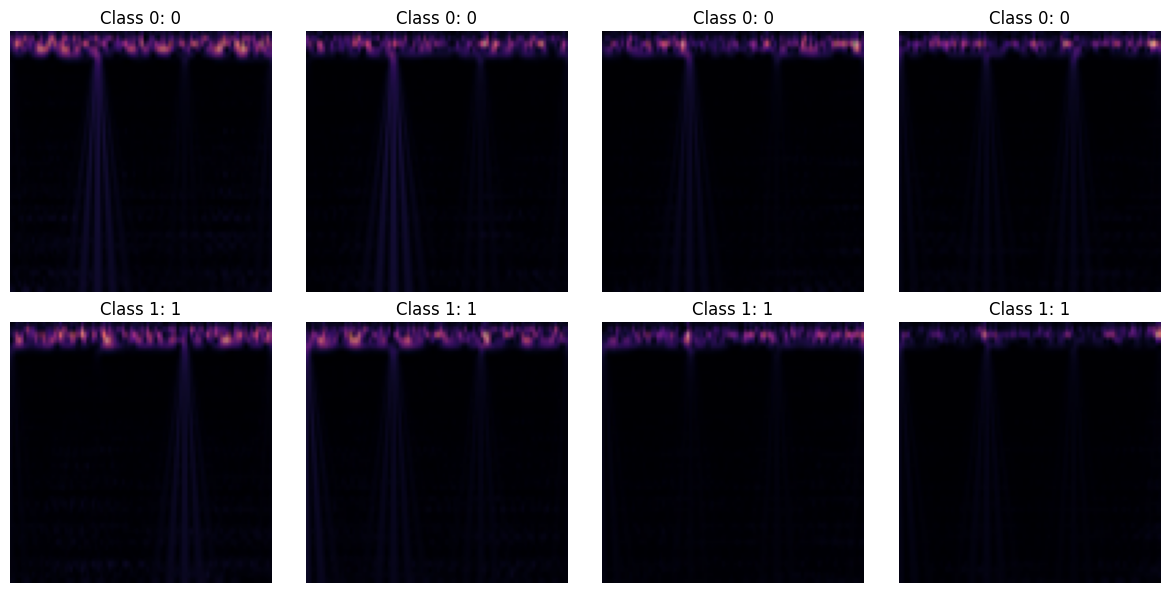

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

idx_class0 = np.where(y_train == 0)[0][:4]
idx_class1 = np.where(y_train == 1)[0][:4]

for ax, idx in zip(axes[0], idx_class0):
    ax.imshow(X_train_img[idx])
    ax.set_title(f"Class 0: {class_names[0]}")
    ax.axis("off")

for ax, idx in zip(axes[1], idx_class1):
    ax.imshow(X_train_img[idx])
    ax.set_title(f"Class 1: {class_names[1]}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "sample_scalograms.png", dpi=200)
plt.show()

In [19]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_img,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
    shuffle=True
)

print("Train:", X_train_final.shape, y_train_final.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test_img.shape, y_test.shape)

Train: (320, 96, 96, 3) (320,)
Val  : (80, 96, 96, 3) (80,)
Test : (320, 96, 96, 3) (320,)


In [20]:
class EEGImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.transpose(0, 3, 1, 2), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = EEGImageDataset(X_train_final, y_train_final)
val_ds = EEGImageDataset(X_val, y_val)
test_ds = EEGImageDataset(X_test_img, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

Dataset sizes: 320 80 320


In [21]:
class EEGScalogramCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

model = EEGScalogramCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

EEGScalogramCNN(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1536, out_feat

In [23]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses, y_true_all, y_pred_all = [], [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        losses.append(loss.item())
        y_true_all.extend(yb.cpu().numpy().astype(int).tolist())
        y_pred_all.extend(preds.cpu().numpy().astype(int).tolist())

    acc = accuracy_score(y_true_all, y_pred_all)
    return np.mean(losses), acc, y_true_all, y_pred_all

In [24]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = -1.0
best_model_path = MODELS_DIR / "best_lab5_samara_cnn.pt"

for epoch in range(1, 13):
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

Epoch 01 | train_loss=0.7540 | val_loss=0.6941 | train_acc=0.4813 | val_acc=0.5000
Epoch 02 | train_loss=0.7090 | val_loss=0.6937 | train_acc=0.5000 | val_acc=0.5000
Epoch 03 | train_loss=0.6921 | val_loss=0.6932 | train_acc=0.5344 | val_acc=0.5000
Epoch 04 | train_loss=0.6986 | val_loss=0.6933 | train_acc=0.5125 | val_acc=0.5000
Epoch 05 | train_loss=0.6879 | val_loss=0.6933 | train_acc=0.5125 | val_acc=0.5000
Epoch 06 | train_loss=0.6918 | val_loss=0.6934 | train_acc=0.5156 | val_acc=0.5000
Epoch 07 | train_loss=0.6876 | val_loss=0.6928 | train_acc=0.5406 | val_acc=0.6625
Epoch 08 | train_loss=0.6837 | val_loss=0.6924 | train_acc=0.5750 | val_acc=0.5000
Epoch 09 | train_loss=0.6775 | val_loss=0.6918 | train_acc=0.6656 | val_acc=0.6625
Epoch 10 | train_loss=0.6789 | val_loss=0.6908 | train_acc=0.6031 | val_acc=0.6250
Epoch 11 | train_loss=0.6740 | val_loss=0.6888 | train_acc=0.6062 | val_acc=0.6375
Epoch 12 | train_loss=0.6575 | val_loss=0.6861 | train_acc=0.6375 | val_acc=0.7250


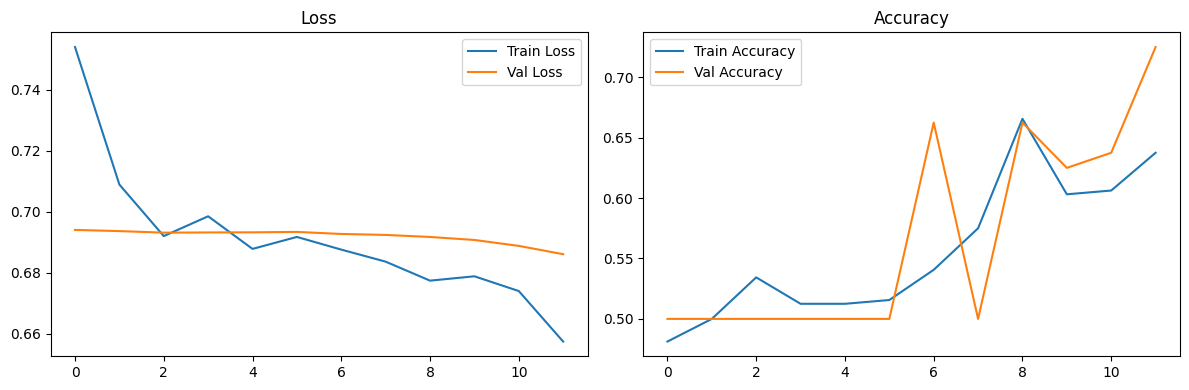

In [25]:
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["val_loss"], label="Val Loss")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Accuracy")
ax[1].plot(history["val_acc"], label="Val Accuracy")
ax[1].set_title("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves.png", dpi=200)
plt.show()

In [26]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader, criterion)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test loss     = {test_loss:.4f}")
print(f"Test accuracy = {test_acc:.4f}")
print(f"Precision     = {precision:.4f}")
print(f"Recall        = {recall:.4f}")
print(f"F1-score      = {f1:.4f}")
print("Confusion matrix:")
print(cm)

Test loss     = 0.6861
Test accuracy = 0.6469
Precision     = 0.6715
Recall        = 0.5750
F1-score      = 0.6195
Confusion matrix:
[[115  45]
 [ 68  92]]


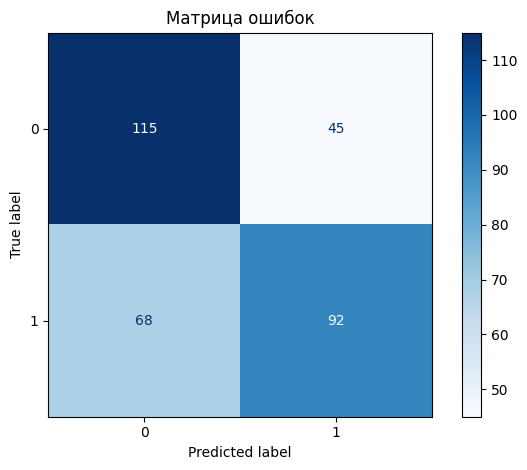

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=200)
plt.show()

In [28]:
summary = {
    "task": "EEG motor imagery classification",
    "train_file": str(train_signal_path),
    "test_file": str(test_signal_path),
    "train_target_file": str(train_target_path),
    "test_target_file": str(test_target_path),
    "train_shape": list(X_train_raw.shape),
    "test_shape": list(X_test_raw.shape),
    "image_shape_train": list(X_train_img.shape),
    "image_shape_test": list(X_test_img.shape),
    "class_mapping": class_mapping,
    "wavelet": WAVELET,
    "scales": [int(SCALES.min()), int(SCALES.max())],
    "best_validation_accuracy": float(best_val_acc),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist(),
    "best_model_path": str(best_model_path),
}

with open(RESULTS_DIR / "experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary

{'task': 'EEG motor imagery classification',
 'train_file': '/kaggle/input/datasets/ahmadhamed1046/lab-5-samara1/MI-EEG-B9T.csv',
 'test_file': '/kaggle/input/datasets/ahmadhamed1046/lab05-sa13/MI-EEG-B9E.csv',
 'train_target_file': '/kaggle/input/datasets/ahmadhamed1046/lab05-samara3/2class_MI_EEG_train_9.csv',
 'test_target_file': '/kaggle/input/datasets/ahmadhamed1046/lab05-sa2/2class_MI_EEG_test_9.csv',
 'train_shape': [400, 3000],
 'test_shape': [320, 3000],
 'image_shape_train': [400, 96, 96, 3],
 'image_shape_test': [320, 96, 96, 3],
 'class_mapping': {'0': 0, '1': 1},
 'wavelet': 'morl',
 'scales': [1, 48],
 'best_validation_accuracy': 0.725,
 'test_loss': 0.6861219644546509,
 'test_accuracy': 0.646875,
 'precision': 0.6715328467153284,
 'recall': 0.575,
 'f1_score': 0.6195286195286195,
 'confusion_matrix': [[115, 45], [68, 92]],
 'best_model_path': '/kaggle/working/lab5_results/models/best_lab5_samara_cnn.pt'}